# Getting Started

This notebook walks through the core primitives of the `ped` framework:

1. Build a **ScoreCard** module and run it standalone with `module.execute()`
2. Build a **DecisionTable** module and run it standalone
3. Combine both in a **FlowConfiguration** and run via `flow.build_graph()` / `graph.execute()`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import polars as pl
import asyncio

---
## 1. Sample data

A small credit-bureau-style dataset we'll reuse throughout.

In [2]:
data = pl.LazyFrame({
    "customer_id":          [1,        2,        3,        4,        5       ],
    "income":               [30000,    75000,    50000,    120000,   45000   ],
    "debt_to_income":       [0.6,      0.2,      0.35,     0.1,      0.5     ],
    "credit_history_years": [1,        12,       5,        20,       3       ],
    "employment_status":    ["part_time", "full_time", "full_time", "full_time", "unemployed"],
})

data.collect()

customer_id,income,debt_to_income,credit_history_years,employment_status
i64,i64,f64,i64,str
1,30000,0.6,1,"""part_time"""
2,75000,0.2,12,"""full_time"""
3,50000,0.35,5,"""full_time"""
4,120000,0.1,20,"""full_time"""
5,45000,0.5,3,"""unemployed"""


---
## 2. ScoreCard module

A `ScoreCard` holds a list of `ScoredVariable`s, each of which maps a column
to a numeric score via **bins**.  The card then sums all scores into a single
`score` output node.

In [3]:
from ped.modules.credit.scorecard.module import ScoreCard, ScoredVariable
from ped.modules.credit.scorecard.impl import BoundBin, ValuesBin, DefaultBin

scorecard = ScoreCard(
    name="my_scorecard",
    variables=[
        ScoredVariable(
            name="income_var",
            variable_name="income",
            bins=[
                BoundBin(value=50,  lower_bound=None,   upper_bound=30000),
                BoundBin(value=100, lower_bound=30000,  upper_bound=60000),
                BoundBin(value=150, lower_bound=60000,  upper_bound=100000),
                BoundBin(value=200, lower_bound=100000, upper_bound=None),
            ],
            default=DefaultBin(value=75),
            value_output_name="income_score",
        ),
        ScoredVariable(
            name="dti_var",
            variable_name="debt_to_income",
            bins=[
                BoundBin(value=200, lower_bound=None, upper_bound=0.2),
                BoundBin(value=150, lower_bound=0.2,  upper_bound=0.4),
                BoundBin(value=100, lower_bound=0.4,  upper_bound=0.6),
                BoundBin(value=50,  lower_bound=0.6,  upper_bound=None),
            ],
            default=DefaultBin(value=100),
            value_output_name="dti_score",
        ),
        ScoredVariable(
            name="employment_var",
            variable_name="employment_status",
            bins=[
                ValuesBin(value=150, items=["full_time"]),
                ValuesBin(value=100, items=["part_time"]),
                ValuesBin(value=50,  items=["unemployed"]),
            ],
            default=DefaultBin(value=75),
            value_output_name="employment_score",
        ),
    ],
    score_output_name="score",
)

print("ScoreCard created:", scorecard.name)

/opt/miniconda/envs/dspdev/lib/python3.10/site-packages/pyspark/pandas/__init__.py:43: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


ScoreCard created: my_scorecard


### 2a. Execute the ScoreCard standalone

`module.execute()` is a convenience method that wraps the module in a
temporary `ConstructedGraphModules`, builds a Hamilton graph, and runs it.
The `outputs` default to `["<module_name>.<output_name>"]`.

In [4]:
# Some useful debugging code
# dr = scorecard.as_constructed_graph_modules().build_graph(output_nodes=[]).hamilton_driver
# scorecard.expand_nodes()
# for k,v in dr.graph.nodes.items():
#     print(k, v.input_types)
# dr.graph.nodes.keys()

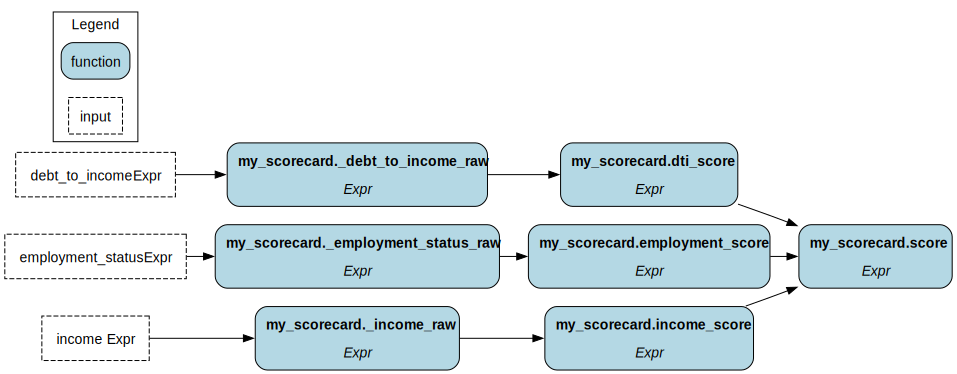

In [5]:
scorecard.as_constructed_graph_modules().build_graph(output_nodes=[]).hamilton_driver

In [6]:
# TODO think in our execute we need to make things simpler like if 
# someone passes in a lazy frame we automatically return a lazy frame
# if its a dict of expressions then we either return a dict of expressions or a lazy frame depending
# on the graph
# unless we always return a lazy frame do we automatically run the collect should it be execute(collect=True) or something like that

sc_result = scorecard.execute(
    inputs={
        "income":               pl.col("income"),
        "debt_to_income":       pl.col("debt_to_income"),
        "employment_status":    pl.col("employment_status"),
        "__dataframe__":        data,   # Hamilton's LazyFrame input
    },
)

print("Score output key:", list(sc_result.keys()))

scored_results = data.with_columns(sc_result["my_scorecard.score"].alias("score"))
scored_results.collect()

Score output key: ['my_scorecard.score']


customer_id,income,debt_to_income,credit_history_years,employment_status,score
i64,i64,f64,i64,str,i32
1,30000,0.6,1,"""part_time""",250
2,75000,0.2,12,"""full_time""",500
3,50000,0.35,5,"""full_time""",400
4,120000,0.1,20,"""full_time""",550
5,45000,0.5,3,"""unemployed""",250


Please just skip 2b for now its under construction
---
## 2b. Pipeline operator — ScoreCard | ProbabilityDefault

Modules can be composed with `|` to form a **chain**.  Each module's
`output_name` is automatically wired to the next module's `input_name`.

The chain produces fully-qualified node names in the form
`<chain_name>.<sub_module_name>.<node_name>`.


In [ ]:

print("Chain type:", type(pipeline).__name__)
print("Sub-modules:", [m.name for m in pipeline.modules])

pd_result = pipeline.execute(
    inputs={
        "income":            pl.col("income"),
        "debt_to_income":    pl.col("debt_to_income"),
        "employment_status": pl.col("employment_status"),
    },
    outputs=["my_scorecard.pd.output"],  # <chain>.<sub_module>.<node>
)

print("Pipeline output key:", list(pd_result.keys()))
data.with_columns(pd_result["my_scorecard.pd.output"].alias("probability_of_default")).collect()


-------------------------------------------------------------------
Oh no an error! Need help with Hamilton?
Join our slack and ask for help! https://join.slack.com/t/hamilton-opensource/shared_invite/zt-2niepkra8-DGKGf_tTYhXuJWBTXtIs4g
-------------------------------------------------------------------



Chain type: ChainModule
Sub-modules: ['my_scorecard', 'pd']


ValueError: 1 errors encountered: 
  Error: Required input my_scorecard.score not provided for nodes: ['my_scorecard.pd.output'].

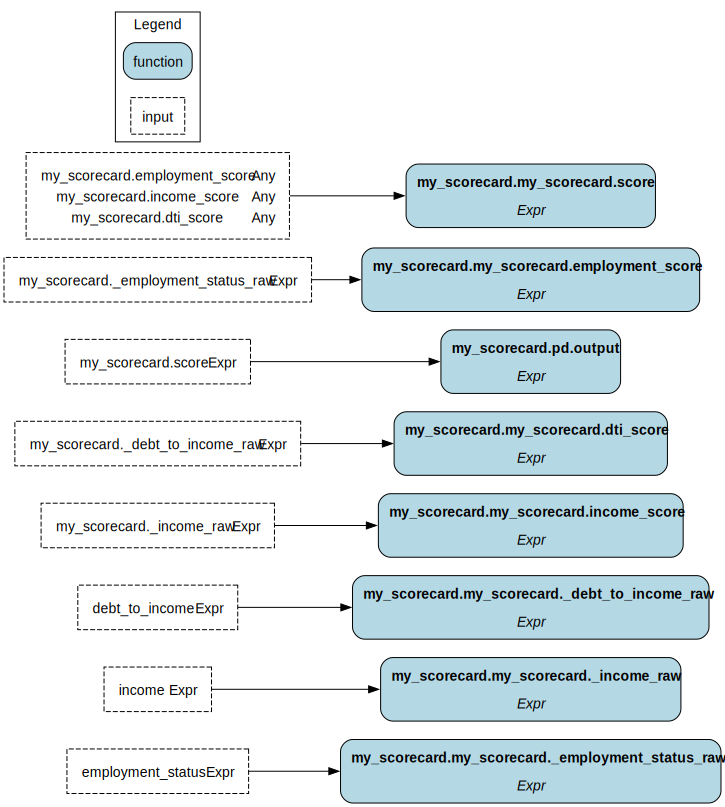

In [8]:
from ped.modules.credit.scorecard.module import ProbabilityDefault

pipeline = scorecard | ProbabilityDefault(name="pd")
pipeline.as_constructed_graph_modules().build_graph(output_nodes=[]).hamilton_driver

---
## 3. Decision Table module

A `DecisionTableModule` evaluates a polars boolean expression against a
parameter table and returns the first matching row's output columns as a
struct.

In [8]:
from ped.modules.credit.decision_table.module import DecisionTableModule
from ped.modules.credit.decision_table.config import ParametersConfig, BetweenExpression, InExpression, AndExpression

decision_table = DecisionTableModule(
    name="risk_band",
    parameters=ParametersConfig(
        columns=["min_score", "max_score", "risk_label"],
        values=[
            [0,   300, "high"],
            [300, 450, "medium"],
            [450, 600, "low"],
        ],
        dtypes={"min_score": "int", "max_score": "int", "risk_label": "string"},
    ),
    expression=BetweenExpression(
        variable="score",
        lower_bound_column="min_score",
        upper_bound_column="max_score",
        mode="lower_inclusive",
    ),
    outputs=["risk_label"],
    default=["unknown"],
)

print("DecisionTable created:", decision_table.name)

DecisionTable created: risk_band


In [9]:
decision_table.expand_nodes()[0].input_map

{'score': 'score'}

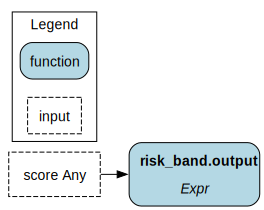

In [10]:
decision_table.as_constructed_graph_modules().build_graph(output_nodes=[]).hamilton_driver

### 3a. Execute the Decision Table standalone

The decision table expects a `score` input — we pass the raw score expression
from the scorecard result.

In [11]:
dt_result = decision_table.execute(
    inputs={
        "score":         pl.col("score"),
        # Provide a dataframe that already has the score column
    },
)

print("DT output key:", list(dt_result.keys()))
scored_results.with_columns(dt_result["risk_band.output"]).collect()

DT output key: ['risk_band.output']


customer_id,income,debt_to_income,credit_history_years,employment_status,score,risk_band.output
i64,i64,f64,i64,str,i32,struct[1]
1,30000,0.6,1,"""part_time""",250,"{""high""}"
2,75000,0.2,12,"""full_time""",500,"{""low""}"
3,50000,0.35,5,"""full_time""",400,"{""medium""}"
4,120000,0.1,20,"""full_time""",550,"{""low""}"
5,45000,0.5,3,"""unemployed""",250,"{""high""}"


---
## 4. Combining modules in a FlowConfiguration

A `FlowConfiguration` is the production-ready way to define a pipeline.  It
accepts module definitions as plain dicts (so they can come from YAML/JSON
with OmegaConf interpolation), resolves parameter sources, and builds a
single Hamilton graph that runs both modules together.

In [ ]:
from ped.flow import FlowConfiguration

# as_config() serialises the module to a plain dict (exclude_defaults=True),
# keeping 'type' so FlowConfiguration can re-hydrate via the discriminated union.
print("scorecard.as_config():")
import json; print(json.dumps(scorecard.as_config(), indent=2, default=str))


In [ ]:
flow = FlowConfiguration(
    metadata={
        "name": "credit_scoring_demo",
        "description": "Scorecard → risk band decision table",
        "author": "getting_started notebook",
    },
    modules=[
        # ── ScoreCard ─────────────────────────────────────────────────────
        scorecard.as_config(),
        # ── Decision Table ────────────────────────────────────────────────
        # Merge the serialised config with the cross-module input_mapping wire
        {
            **decision_table.as_config(),
            "input_mapping": {"score": "my_scorecard.score"},  # scorecard → DT
        },
    ],
    outputs=["risk_band.output"],
)

print("Flow created:", flow.metadata.name)


### 4a. Build & execute the flow

`flow.build_graph()` is async (parameter sources are resolved asynchronously).
In a notebook we can use `asyncio.run()` or `await` directly.

In [ ]:
graph = await flow.build_graph(
    inputs={
        "income":            pl.col("income"),
        "debt_to_income":    pl.col("debt_to_income"),
        "employment_status": pl.col("employment_status"),
        "__dataframe__":     data,
    }
)

print("Graph built:", type(graph).__name__)

In [ ]:
result = graph.execute(
    inputs={
        "income":            pl.col("income"),
        "debt_to_income":    pl.col("debt_to_income"),
        "employment_status": pl.col("employment_status"),
        "__dataframe__":     data,
    },
)

print("Output keys:", list(result.keys()))
result["risk_band.output"].collect()

---
## 5. Requesting extra intermediate outputs

Pass `output_overrides` to `graph.execute()` to pull any intermediate node
without rebuilding the graph.

In [ ]:
inputs = {
    "income":            pl.col("income"),
    "debt_to_income":    pl.col("debt_to_income"),
    "employment_status": pl.col("employment_status"),
    "__dataframe__":     data,
}

detailed = graph.execute(
    inputs=inputs,
    output_overrides=[
        "my_scorecard.income_score",
        "my_scorecard.dti_score",
        "my_scorecard.employment_score",
        "my_scorecard.score",
        "risk_band.output",
    ],
)

summary = data.collect().with_columns(
    detailed["my_scorecard.income_score"].collect().to_series().alias("income_score"),
    detailed["my_scorecard.dti_score"].collect().to_series().alias("dti_score"),
    detailed["my_scorecard.employment_score"].collect().to_series().alias("employment_score"),
    detailed["my_scorecard.score"].collect().to_series().alias("total_score"),
    detailed["risk_band.output"].collect().to_series().struct.field("risk_label").alias("risk_label"),
)
summary